## Low Level Understanding of Data

In [2]:
import pandas as pd

### Univariate Analysis(Categorical Data Type)

In [3]:
df=pd.read_csv("C:/Users/Divyanshi Kesharwani/Downloads/Data.csv")
print(df)

   Country   Age   Salary Purchased
0   France  44.0  72000.0        No
1    Spain  27.0  48000.0       Yes
2  Germany  30.0  54000.0        No
3    Spain  38.0  61000.0        No
4  Germany  40.0      NaN       Yes
5   France  35.0  58000.0       Yes
6    Spain   NaN  52000.0        No
7   France  48.0  79000.0       Yes
8  Germany  50.0  83000.0        No
9   France  37.0  67000.0       Yes


In [4]:
df.dtypes

Country       object
Age          float64
Salary       float64
Purchased     object
dtype: object

In [5]:
df["Country"].value_counts()

Country
France     4
Spain      3
Germany    3
Name: count, dtype: int64

In [6]:
df["Country"].value_counts(normalize=True)

Country
France     0.4
Spain      0.3
Germany    0.3
Name: proportion, dtype: float64

In [7]:
df["Country"].value_counts(normalize=True)*100

Country
France     40.0
Spain      30.0
Germany    30.0
Name: proportion, dtype: float64

<Axes: xlabel='Country'>

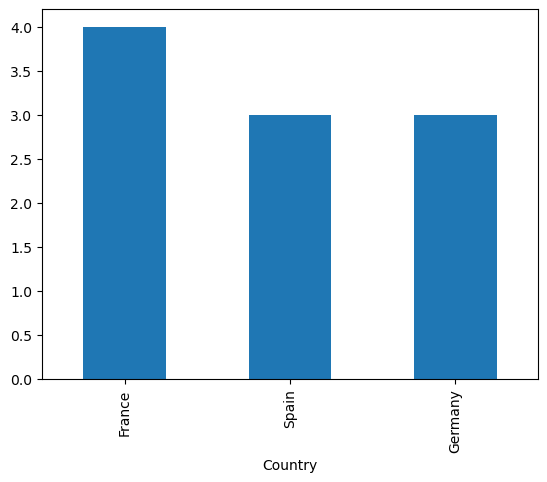

In [8]:
df["Country"].value_counts().plot(kind="bar")

<Axes: ylabel='count'>

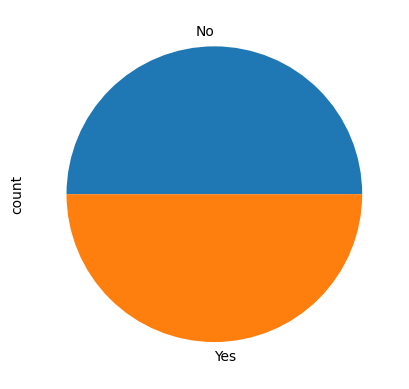

In [9]:
df["Purchased"].value_counts().plot(kind="pie")

### Univariate Analysis(Numerical Data Type)

<Axes: ylabel='Frequency'>

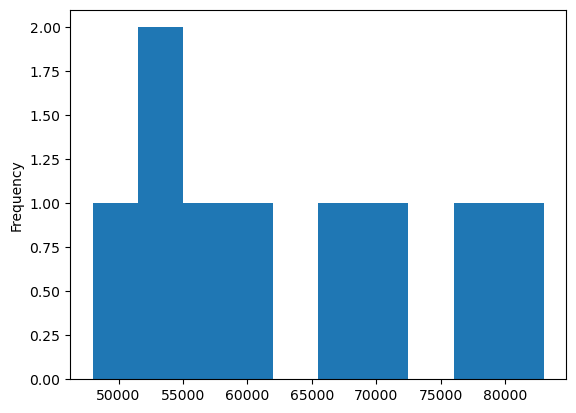

In [12]:
df["Salary"].plot(kind="hist")

<Axes: ylabel='Density'>

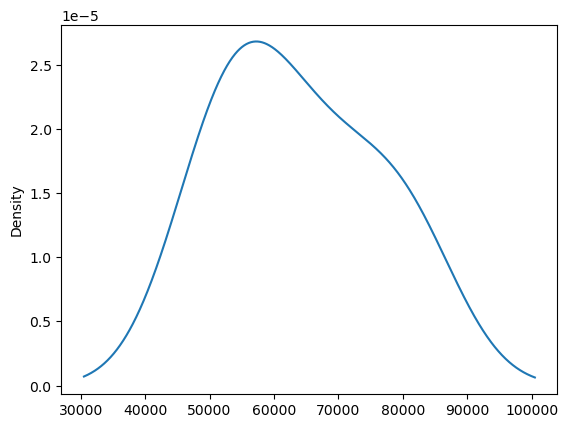

In [13]:
df["Salary"].plot(kind="kde")

### Bivariate Analysis(Categorical Data Types)

In [15]:
pd.crosstab(df["Country"],df["Purchased"])

Purchased,No,Yes
Country,,
France,1,3
Germany,2,1
Spain,2,1


In [16]:
pd.crosstab(df["Country"],df["Purchased"],margins=True)

Purchased,No,Yes,All
Country,,,
France,1,3,4
Germany,2,1,3
Spain,2,1,3
All,5,5,10


### Bivariate Analysis(Numerical Data Types)

Correlation is the relation of two numericals column with each other.

In [19]:
df.corr(numeric_only=True)

,Age,Salary
Age,1.000000,0.982495
Salary,0.982495,1.000000


<Axes: >

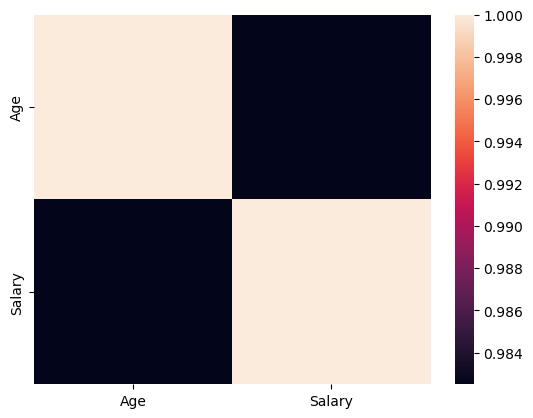

In [21]:
import seaborn as sns
sns.heatmap(df.corr(numeric_only=True))

<Axes: >

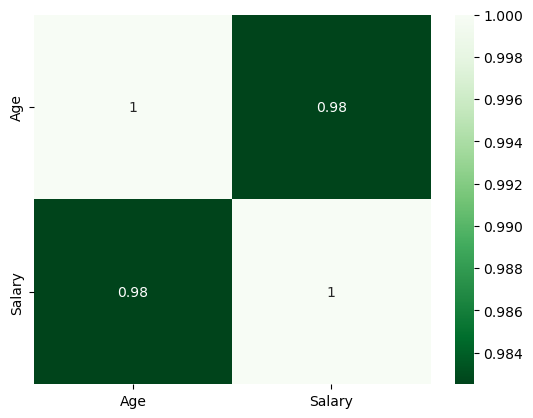

In [26]:
import seaborn as sns
sns.heatmap(df.corr(numeric_only=True),cmap="Greens_r",annot=True)

### Bivariate Analysis(Numeric and Categorical Data)

<Axes: xlabel='Country', ylabel='Salary'>

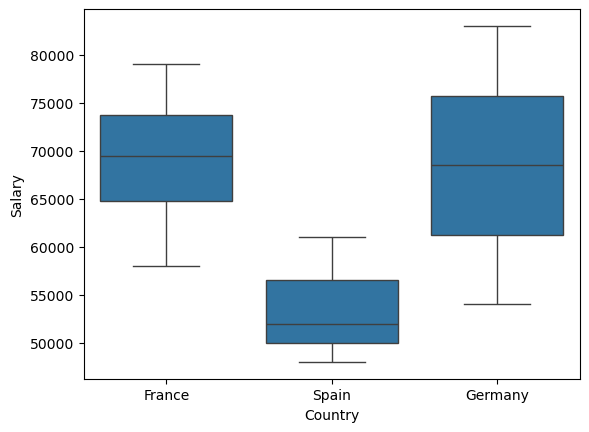

In [28]:
sns.boxplot(x="Country",y="Salary",data=df)

## Multivariate Analysis

## Data Cleaning

In [46]:
df.duplicated()

0    False
1    False
2    False
3    False
4    False
5    False
6    False
7    False
8    False
9    False
dtype: bool

In [30]:
df.duplicated().sum()

np.int64(0)

In [32]:
d=df.drop_duplicates()
print(d)

   Country   Age   Salary Purchased
0   France  44.0  72000.0        No
1    Spain  27.0  48000.0       Yes
2  Germany  30.0  54000.0        No
3    Spain  38.0  61000.0        No
4  Germany  40.0      NaN       Yes
5   France  35.0  58000.0       Yes
6    Spain   NaN  52000.0        No
7   France  48.0  79000.0       Yes
8  Germany  50.0  83000.0        No
9   France  37.0  67000.0       Yes


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Country    10 non-null     object 
 1   Age        9 non-null      float64
 2   Salary     9 non-null      float64
 3   Purchased  10 non-null     object 
dtypes: float64(2), object(2)
memory usage: 452.0+ bytes


In [34]:
df.isnull()

,Country,Age,Salary,Purchased
0,False,False,False,False
1,False,False,False,False
2,False,False,False,False
3,False,False,False,False
4,False,False,True,False
5,False,False,False,False
6,False,True,False,False
7,False,False,False,False
8,False,False,False,False
9,False,False,False,False


In [35]:
df.isnull().sum()

Country      0
Age          1
Salary       1
Purchased    0
dtype: int64

In [42]:
df["Age"]=df["Age"].fillna(df["Age"].mode()[0])
print(df["Age"])

0    44.0
1    27.0
2    30.0
3    38.0
4    40.0
5    35.0
6    27.0
7    48.0
8    50.0
9    37.0
Name: Age, dtype: float64


In [43]:
df["Age"].mode()[0]

np.float64(27.0)

In [44]:
df["Salary"]=df["Salary"].fillna(df["Salary"].mode()[0])
print(df["Salary"])

0    72000.0
1    48000.0
2    54000.0
3    61000.0
4    48000.0
5    58000.0
6    52000.0
7    79000.0
8    83000.0
9    67000.0
Name: Salary, dtype: float64


In [45]:
df.isnull()

,Country,Age,Salary,Purchased
0,False,False,False,False
1,False,False,False,False
2,False,False,False,False
3,False,False,False,False
4,False,False,False,False
5,False,False,False,False
6,False,False,False,False
7,False,False,False,False
8,False,False,False,False
9,False,False,False,False


## Feature Engineering

In [48]:
df["Ratio"]=df["Salary"]/df["Age"]
print(df)

   Country   Age   Salary Purchased        Ratio
0   France  44.0  72000.0        No  1636.363636
1    Spain  27.0  48000.0       Yes  1777.777778
2  Germany  30.0  54000.0        No  1800.000000
3    Spain  38.0  61000.0        No  1605.263158
4  Germany  40.0  48000.0       Yes  1200.000000
5   France  35.0  58000.0       Yes  1657.142857
6    Spain  27.0  52000.0        No  1925.925926
7   France  48.0  79000.0       Yes  1645.833333
8  Germany  50.0  83000.0        No  1660.000000
9   France  37.0  67000.0       Yes  1810.810811


In [50]:
df["Percentage"]=(df["Salary"]/df["Age"])*100
print(df)

   Country   Age   Salary Purchased        Ratio     Percentage
0   France  44.0  72000.0        No  1636.363636  163636.363636
1    Spain  27.0  48000.0       Yes  1777.777778  177777.777778
2  Germany  30.0  54000.0        No  1800.000000  180000.000000
3    Spain  38.0  61000.0        No  1605.263158  160526.315789
4  Germany  40.0  48000.0       Yes  1200.000000  120000.000000
5   France  35.0  58000.0       Yes  1657.142857  165714.285714
6    Spain  27.0  52000.0        No  1925.925926  192592.592593
7   France  48.0  79000.0       Yes  1645.833333  164583.333333
8  Germany  50.0  83000.0        No  1660.000000  166000.000000
9   France  37.0  67000.0       Yes  1810.810811  181081.081081


In [54]:
#Binning
def bin(x):
    if((x["Purchased"]=="Yes") & (x["Salary"]>50000)):
        return True
    else:
        return False

In [57]:
df["Bin"]=df.apply(bin,axis=1)
print(df)

   Country   Age   Salary Purchased        Ratio     Percentage    Bin
0   France  44.0  72000.0        No  1636.363636  163636.363636  False
1    Spain  27.0  48000.0       Yes  1777.777778  177777.777778  False
2  Germany  30.0  54000.0        No  1800.000000  180000.000000  False
3    Spain  38.0  61000.0        No  1605.263158  160526.315789  False
4  Germany  40.0  48000.0       Yes  1200.000000  120000.000000  False
5   France  35.0  58000.0       Yes  1657.142857  165714.285714   True
6    Spain  27.0  52000.0        No  1925.925926  192592.592593  False
7   France  48.0  79000.0       Yes  1645.833333  164583.333333   True
8  Germany  50.0  83000.0        No  1660.000000  166000.000000  False
9   France  37.0  67000.0       Yes  1810.810811  181081.081081   True


## Data Analysis

### Filtering the Data

In [60]:
df.loc[df["Country"]=="France"]

,Country,Age,Salary,Purchased,Ratio,Percentage,Bin
0,France,44.0,72000.0,No,1636.363636,163636.363636,False
5,France,35.0,58000.0,Yes,1657.142857,165714.285714,True
7,France,48.0,79000.0,Yes,1645.833333,164583.333333,True
9,France,37.0,67000.0,Yes,1810.810811,181081.081081,True


In [65]:
df.loc[(df["Purchased"]=="Yes")&(df["Country"]=="France")]

,Country,Age,Salary,Purchased,Ratio,Percentage,Bin
5,France,35.0,58000.0,Yes,1657.142857,165714.285714,True
7,France,48.0,79000.0,Yes,1645.833333,164583.333333,True
9,France,37.0,67000.0,Yes,1810.810811,181081.081081,True


In [67]:
df.loc[(df["Purchased"]=="No")&(df["Salary"]>=50000)]

,Country,Age,Salary,Purchased,Ratio,Percentage,Bin
0,France,44.0,72000.0,No,1636.363636,163636.363636,False
2,Germany,30.0,54000.0,No,1800.000000,180000.000000,False
3,Spain,38.0,61000.0,No,1605.263158,160526.315789,False
6,Spain,27.0,52000.0,No,1925.925926,192592.592593,False
8,Germany,50.0,83000.0,No,1660.000000,166000.000000,False


In [68]:
for i in enumerate(df.columns):
    print(i)

(0, 'Country')
(1, 'Age')
(2, 'Salary')
(3, 'Purchased')
(4, 'Ratio')
(5, 'Percentage')
(6, 'Bin')


In [69]:
df.iloc[:10,1:3]

,Age,Salary
0,44.0,72000.0
1,27.0,48000.0
2,30.0,54000.0
3,38.0,61000.0
4,40.0,48000.0
5,35.0,58000.0
6,27.0,52000.0
7,48.0,79000.0
8,50.0,83000.0
9,37.0,67000.0


In [70]:
df.iloc[:6,[2,4]]

,Salary,Ratio
0,72000.0,1636.363636
1,48000.0,1777.777778
2,54000.0,1800.000000
3,61000.0,1605.263158
4,48000.0,1200.000000
5,58000.0,1657.142857


### Group By

In [72]:
df.groupby("Country").agg({"Purchased":"sum"})

,Purchased
Country,
France,NoYesYesYes
Germany,NoYesNo
Spain,YesNoNo


In [79]:
df.groupby("Purchased").agg({"Age":"max"})

,Age
Purchased,
No,50.0
Yes,48.0


### Order By

In [80]:
df.sort_values(by="Age")

,Country,Age,Salary,Purchased,Ratio,Percentage,Bin
1,Spain,27.0,48000.0,Yes,1777.777778,177777.777778,False
6,Spain,27.0,52000.0,No,1925.925926,192592.592593,False
2,Germany,30.0,54000.0,No,1800.000000,180000.000000,False
5,France,35.0,58000.0,Yes,1657.142857,165714.285714,True
9,France,37.0,67000.0,Yes,1810.810811,181081.081081,True
3,Spain,38.0,61000.0,No,1605.263158,160526.315789,False
4,Germany,40.0,48000.0,Yes,1200.000000,120000.000000,False
0,France,44.0,72000.0,No,1636.363636,163636.363636,False
7,France,48.0,79000.0,Yes,1645.833333,164583.333333,True
8,Germany,50.0,83000.0,No,1660.000000,166000.000000,False


In [81]:
df.sort_values(by="Age",ascending=False)

,Country,Age,Salary,Purchased,Ratio,Percentage,Bin
8,Germany,50.0,83000.0,No,1660.000000,166000.000000,False
7,France,48.0,79000.0,Yes,1645.833333,164583.333333,True
0,France,44.0,72000.0,No,1636.363636,163636.363636,False
4,Germany,40.0,48000.0,Yes,1200.000000,120000.000000,False
3,Spain,38.0,61000.0,No,1605.263158,160526.315789,False
9,France,37.0,67000.0,Yes,1810.810811,181081.081081,True
5,France,35.0,58000.0,Yes,1657.142857,165714.285714,True
2,Germany,30.0,54000.0,No,1800.000000,180000.000000,False
1,Spain,27.0,48000.0,Yes,1777.777778,177777.777778,False
6,Spain,27.0,52000.0,No,1925.925926,192592.592593,False


In [82]:
df.sort_values(by="Age",ascending=False)[:5]

,Country,Age,Salary,Purchased,Ratio,Percentage,Bin
8,Germany,50.0,83000.0,No,1660.000000,166000.000000,False
7,France,48.0,79000.0,Yes,1645.833333,164583.333333,True
0,France,44.0,72000.0,No,1636.363636,163636.363636,False
4,Germany,40.0,48000.0,Yes,1200.000000,120000.000000,False
3,Spain,38.0,61000.0,No,1605.263158,160526.315789,False
